<a href="https://colab.research.google.com/github/bsy3/abcd/blob/0515/%EC%83%9D%EC%84%B1%ED%98%95_AI%EB%A5%BC_%EC%9D%B4%EC%9A%A9%ED%95%9C_%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5_%EA%B3%A0%EC%96%91%EC%9D%B4_%EA%B0%9D%EC%B2%B4_%EC%9D%B8%EC%8B%9D_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%A8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

고양이가 있는 이미지 2장을 업로드하세요:


Saving 1122.png to 1122 (8).png
Saving 1111111.png to 1111111 (2).png

image 1/1 /content/1122 (8).png: 640x640 4 cats, 6 dogs, 1673.2ms
Speed: 8.0ms preprocess, 1673.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
1122 (8).png에서 감지된 고양이 수: 4마리


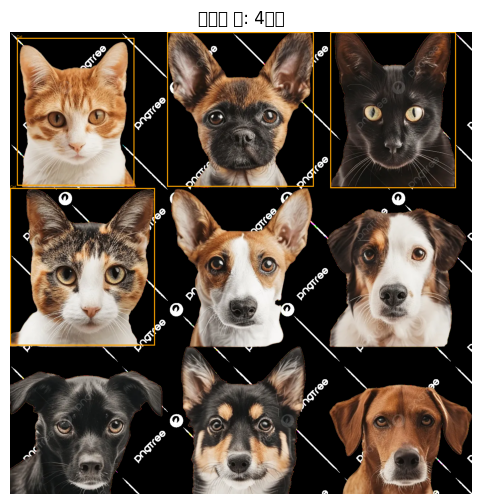


image 1/1 /content/1111111 (2).png: 640x640 5 cats, 6 dogs, 1377.2ms
Speed: 4.9ms preprocess, 1377.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
1111111 (2).png에서 감지된 고양이 수: 5마리


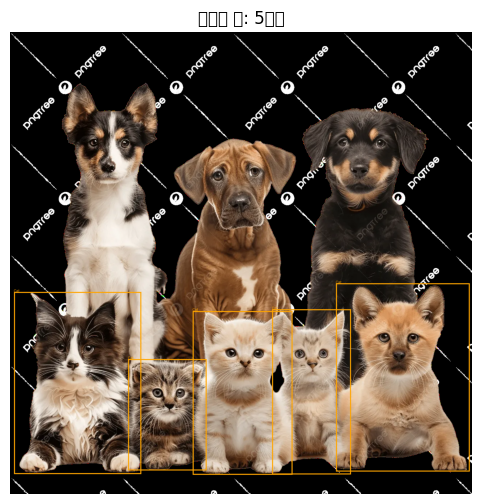

In [22]:
# 1. YOLOv8 설치
!pip install -q ultralytics

# 2. 라이브러리 임포트
from ultralytics import YOLO
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from google.colab import files

# 3. YOLOv8 모델 로드 (정확도 높은 모델 추천)
model = YOLO('yolov8m.pt')  # 필요 시 yolov8s.pt, l.pt, x.pt 등도 사용 가능

# 4. 이미지 업로드
print("고양이가 있는 이미지 2장을 업로드하세요:")
uploaded = files.upload()
image_paths = list(uploaded.keys())

# 5. COCO 기준 고양이 클래스 ID
CAT_CLASS_ID = 15

# 6. 이미지 처리 및 고양이 감지만 시각화
for image_path in image_paths:
    results = model(image_path)
    boxes = results[0].boxes

    # 이미지 로딩
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    # 고양이 감지 박스만 그리기
    cat_count = 0
    for box in boxes:
        class_id = int(box.cls.item())
        if class_id == CAT_CLASS_ID:
            cat_count += 1
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            draw.rectangle([x1, y1, x2, y2], outline="orange", width=3)
            draw.text((x1, y1 - 10), "Cat", fill="orange")

    # 고양이 수 출력
    print(f"{image_path}에서 감지된 고양이 수: {cat_count}마리")

    # 결과 이미지 출력
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"고양이 수: {cat_count}마리")
    plt.show()


